##### (d)

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import os

In [58]:
PLOT_COLORS = ['red', 'green', 'blue', 'orange']  # Colors for your plots
K = 4           # Number of Gaussians in the mixture model
NUM_TRIALS = 3  # Number of trials to run (can be adjusted for debugging)
UNLABELED = -1  # Cluster label for unlabeled data points (do not change)

In [59]:
def load_gmm_dataset(csv_path):
    """Load dataset for Gaussian Mixture Model (problem 3).

    Args:
         csv_path: Path to CSV file containing dataset.

    Returns:
        x: NumPy array shape (m, n)
        z: NumPy array shape (m, 1)

    NOTE: You do not need to edit this function.
    """

    # Load headers
    with open(csv_path, 'r') as csv_fh:
        headers = csv_fh.readline().strip().split(',')

    # Load features and labels
    x_cols = [i for i in range(len(headers)) if headers[i].startswith('x')]
    z_cols = [i for i in range(len(headers)) if headers[i] == 'z']

    x = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=x_cols, dtype=float)
    z = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=z_cols, dtype=float)

    if z.ndim == 1:
        z = np.expand_dims(z, axis=-1)

    return x, z

def plot_gmm_preds(x, z, with_supervision, plot_id):
    """Plot GMM predictions on a 2D dataset `x` with labels `z`.

    Write to the output directory, including `plot_id`
    in the name, and appending 'ss' if the GMM had supervision.

    NOTE: You do not need to edit this function.
    """
    plt.figure(figsize=(12, 8))
    plt.title('{} GMM Predictions'.format('Semi-supervised' if with_supervision else 'Unsupervised'))
    plt.xlabel('x_1')
    plt.ylabel('x_2')

    for x_1, x_2, z_ in zip(x[:, 0], x[:, 1], z):
        color = 'gray' if z_ < 0 else PLOT_COLORS[int(z_)]
        alpha = 0.25 if z_ < 0 else 0.75
        plt.scatter(x_1, x_2, marker='.', c=color, alpha=alpha)

    file_name = 'p03_pred{}_{}.pdf'.format('_ss' if with_supervision else '', plot_id)
    save_path = os.path.join('output', file_name)
    plt.plot()
    plt.savefig(save_path)

In [60]:
def run_em(x, w, phi, mu, sigma):
    """Problem 3(d): EM Algorithm (unsupervised).

    See inline comments for instructions.

    Args:
        x: Design matrix of shape (m, n).
        w: Initial weight matrix of shape (m, k).
        phi: Initial mixture prior, of shape (k,).
        mu: Initial cluster means, list of k arrays of shape (n,).
        sigma: Initial cluster covariances, list of k arrays of shape (n, n).

    Returns:
        Updated weight matrix of shape (m, k) resulting from EM algorithm.
        More specifically, w[i, j] should contain the probability of
        example x^(i) belonging to the j-th Gaussian in the mixture.
    """
    # No need to change any of these parameters
    eps = 1e-3  # Convergence threshold
    max_iter = 1000

    # Stop when the absolute change in log-likelihood is < eps
    # See below for explanation of the convergence criterion
    it = 0
    ll = prev_ll = None
    while it < max_iter and (prev_ll is None or np.abs(ll - prev_ll) >= eps):
        # *** START CODE HERE
        m, n = x.shape
        
        # (1) E-step: Update your estimates in w
        for k in range(K):
            x_dot = x-mu[k]
            w[:, k] = 1 / np.sqrt(np.linalg.det(sigma[k])) * np.exp(-0.5 * (x_dot @ np.linalg.inv(sigma[k]) * x_dot).sum(axis=1)) * phi[k]
        w /= w.sum(axis=1, keepdims=True)
        
        # (2) M-step: Update the model parameters phi, mu, and sigma
        phi = w.mean(axis=0)
        mu = (w.T @ x) / w.sum(axis=0)[:,None]
        for k in range(K):
            x_dot = x-mu[k]
            sigma[k] = x_dot.T @ (w[:, k][:,None] * x_dot) / w[:, k].sum()
        
        # (3) Compute the log-likelihood of the data to check for convergence.
        # By log-likelihood, we mean `ll = sum_x[log(sum_z[p(x|z) * p(z)])]`.
        # We define convergence by the first iteration where abs(ll - prev_ll) < eps.
        # Hint: For debugging, recall part (a). We showed that ll should be monotonically increasing.
        it += 1
        prev_ll = ll
        ll=0
        p_xz = np.zeros((m,K))
        for k in range(K):
            x_dot = x-mu[k]
            p_xz[:, k] = 1 / np.sqrt(np.linalg.det(sigma[k])) * np.exp(-0.5 * (x_dot @ np.linalg.inv(sigma[k]) * x_dot).sum(axis=1)) * phi[k]
        ll = np.sum(np.log(p_xz.sum(axis=1)))
        # *** END CODE HERE ***
    print(f'Number of iterations:{it}, Log loss: {ll}')

    return w

In [61]:
def main(is_semi_supervised, trial_num):
    """Problem 3: EM for Gaussian Mixture Models (unsupervised and semi-supervised)"""
    print('Running {} EM algorithm...'
          .format('semi-supervised' if is_semi_supervised else 'unsupervised'))

    # Load dataset
    train_path = os.path.join('data', 'ds3_train.csv')
    x, z = load_gmm_dataset(train_path)
    x_tilde = None

    if is_semi_supervised:
        # Split into labeled and unlabeled examples
        labeled_idxs = (z != UNLABELED).squeeze()
        x_tilde = x[labeled_idxs, :]   # Labeled examples
        z = z[labeled_idxs, :]         # Corresponding labels
        x = x[~labeled_idxs, :]        # Unlabeled examples

    # *** START CODE HERE ***
    # Initialize mu and sigma by splitting the m data points uniformly at random
    # into K groups, then calculating the sample mean and covariance for each group
    m, n = x.shape
    idx = np.random.permutation(m)
    mu = np.ones((K,n))
    sigma = np.ones((K,n,n))

    k_size = m//K
    for k in range(K):
        start = k * k_size
        end = (k+1) * k_size if k!=K-1 else None
        x_k = x[idx[start : end]]
        
        mu[k] = np.average(x_k)
        sigma[k] = np.cov(x_k, rowvar=False)

    phi = np.ones((K,)) / K
    w = np.ones((m,K)) / K
    
    # *** END CODE HERE ***

    if is_semi_supervised:
        w = run_semi_supervised_em(x, x_tilde, z, w, phi, mu, sigma)
    else:
        w = run_em(x, w, phi, mu, sigma)

    # Plot your predictions
    z_pred = np.zeros(m)
    if w is not None:  # Just a placeholder for the starter code
        for i in range(m):
            z_pred[i] = np.argmax(w[i])

    plot_gmm_preds(x, z_pred, is_semi_supervised, plot_id=trial_num)

In [62]:
def run_semi_supervised_em(x, x_tilde, z, w, phi, mu, sigma):
    """Problem 3(e): Semi-Supervised EM Algorithm.

    See inline comments for instructions.

    Args:
        x: Design matrix of unlabeled examples of shape (m, n).
        x_tilde: Design matrix of labeled examples of shape (m_tilde, n).
        z: Array of labels of shape (m_tilde, 1).
        w: Initial weight matrix of shape (m, k).
        phi: Initial mixture prior, of shape (k,).
        mu: Initial cluster means, list of k arrays of shape (n,).
        sigma: Initial cluster covariances, list of k arrays of shape (n, n).

    Returns:
        Updated weight matrix of shape (m, k) resulting from semi-supervised EM algorithm.
        More specifically, w[i, j] should contain the probability of
        example x^(i) belonging to the j-th Gaussian in the mixture.
    """
    # No need to change any of these parameters
    alpha = 20.  # Weight for the labeled examples
    eps = 1e-3   # Convergence threshold
    max_iter = 1000

    # Stop when the absolute change in log-likelihood is < eps
    # See below for explanation of the convergence criterion
    it = 0
    ll = prev_ll = None
    while it < max_iter and (prev_ll is None or np.abs(ll - prev_ll) >= eps):
        # *** START CODE HERE ***
        m, n = x.shape
        m_tilde, _ = x_tilde.shape
        
        # (1) E-step: Update your estimates in w
        for k in range(K):
            x_dot = x-mu[k]
            w[:, k] = 1 / np.sqrt(np.linalg.det(sigma[k])) * np.exp(-0.5 * (x_dot @ np.linalg.inv(sigma[k]) * x_dot).sum(axis=1)) * phi[k]
        w /= w.sum(axis=1, keepdims=True)
        
        # (2) M-step: Update the model parameters phi, mu, and sigma
        for k in range(K):
            mask = z.squeeze() == k
            phi[k] = (w[:, k].sum() + alpha * mask.sum()) / (m + alpha * m_tilde)
            mu[k] = (w[:, k].dot(x) + alpha * x_tilde[mask].sum(axis=0)) / (w[:, k].sum() + alpha * mask.sum())
            
            x_dot = x-mu[k]
            x_tilde_k = (x_tilde-mu[k])[mask]
            nk = w[:, k].sum() + alpha * mask.sum()
            sk = x_dot.T @ (w[:, k][:,None] * x_dot) + alpha * x_tilde_k.T @ x_tilde_k
            sigma[k] = sk / nk
        
        # (3) Compute the log-likelihood of the data to check for convergence.
        # Hint: Make sure to include alpha in your calculation of ll.
        # Hint: For debugging, recall part (a). We showed that ll should be monotonically increasing.
        it += 1
        prev_ll = ll
        ll=0
        
        p_xz = np.zeros((m,K))
        for k in range(K):
            x_dot = x-mu[k]
            p_xz[:, k] = 1 / np.sqrt(np.linalg.det(sigma[k])) * np.exp(-0.5 * (x_dot @ np.linalg.inv(sigma[k]) * x_dot).sum(axis=1)) * phi[k]
            
        ll = np.sum(np.log(p_xz.sum(axis=1)))
        
        for k in range(K):
            mask = z.squeeze()==k
            x_dot = x_tilde[mask] - mu[k]
            
            p = 1 / np.sqrt(np.linalg.det(sigma[k])) * np.exp(-0.5 * (x_dot @ np.linalg.inv(sigma[k]) * x_dot).sum(axis=1)) * phi[k]
            ll += alpha * np.log(p).sum()
            
        # *** END CODE HERE ***
    print(f'Number of iterations:{it}, Log loss: {ll}')

    return w

Running unsupervised EM algorithm...
Number of iterations:116, Log loss: 2.4327480635761063
Running semi-supervised EM algorithm...
Number of iterations:23, Log loss: 191.65744001718812
Running unsupervised EM algorithm...
Number of iterations:120, Log loss: 2.4464730284476204
Running semi-supervised EM algorithm...
Number of iterations:22, Log loss: 191.65790255953556
Running unsupervised EM algorithm...
Number of iterations:91, Log loss: 2.439220257793224
Running semi-supervised EM algorithm...
Number of iterations:23, Log loss: 191.6579598336822


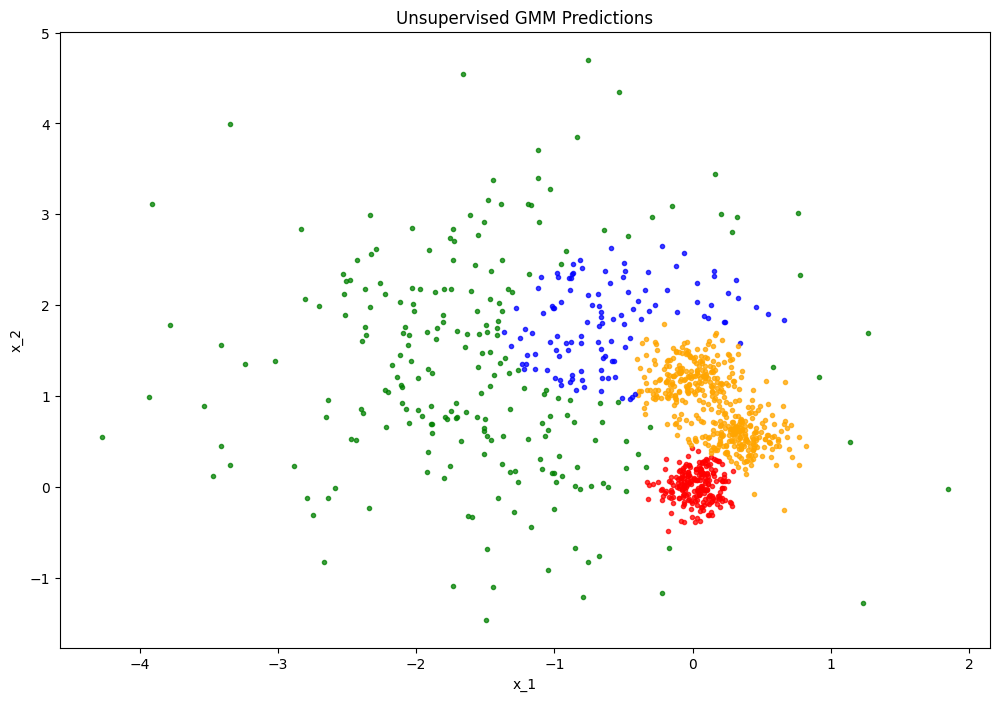

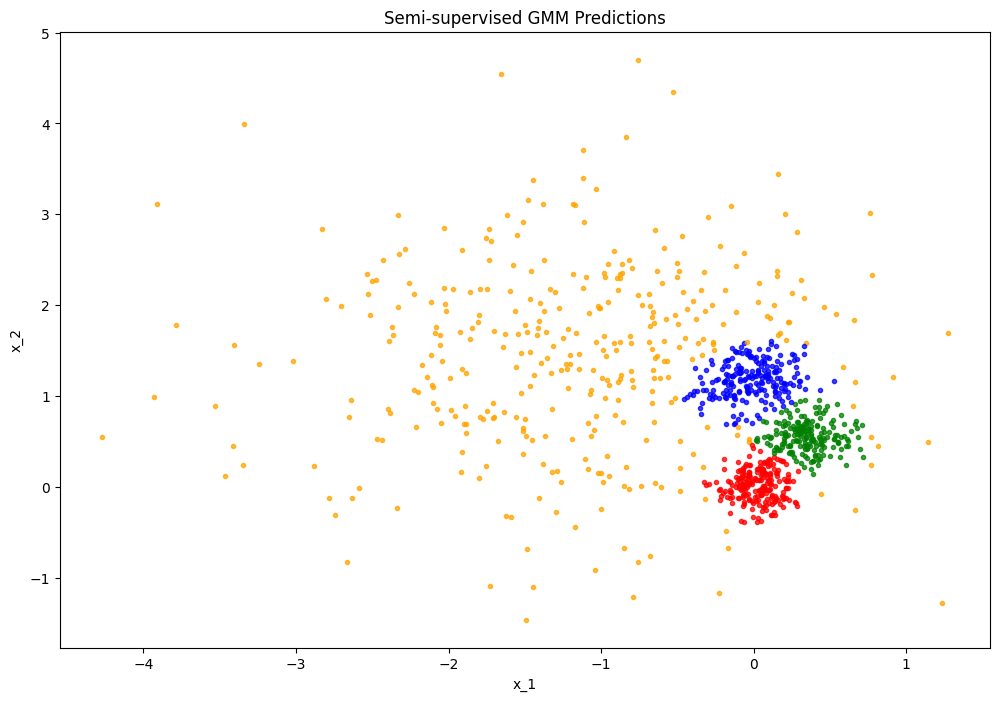

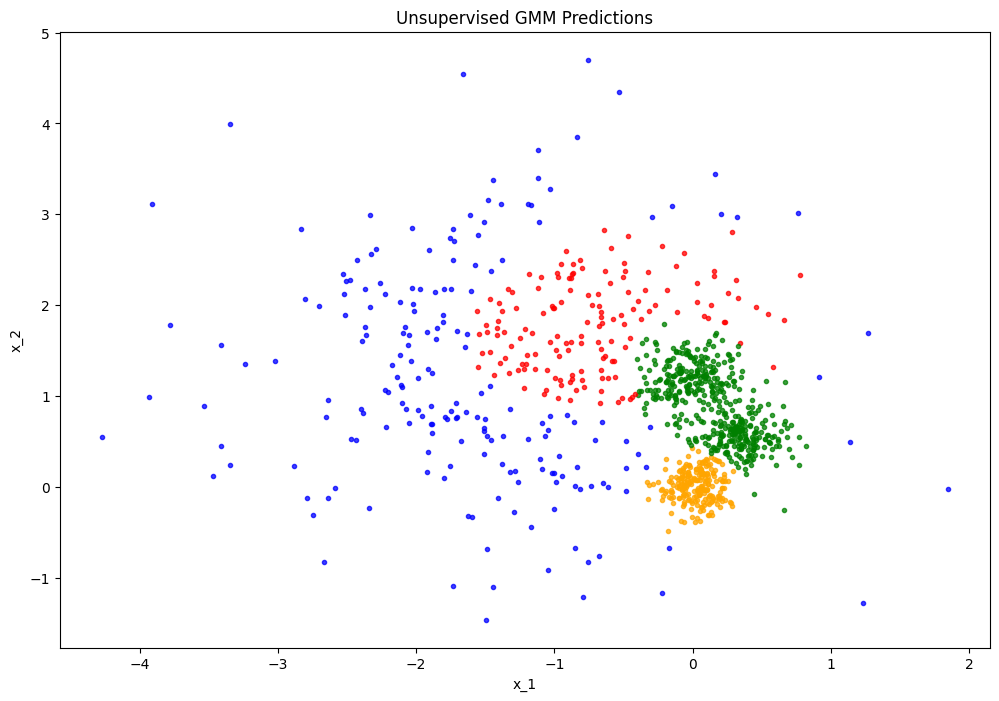

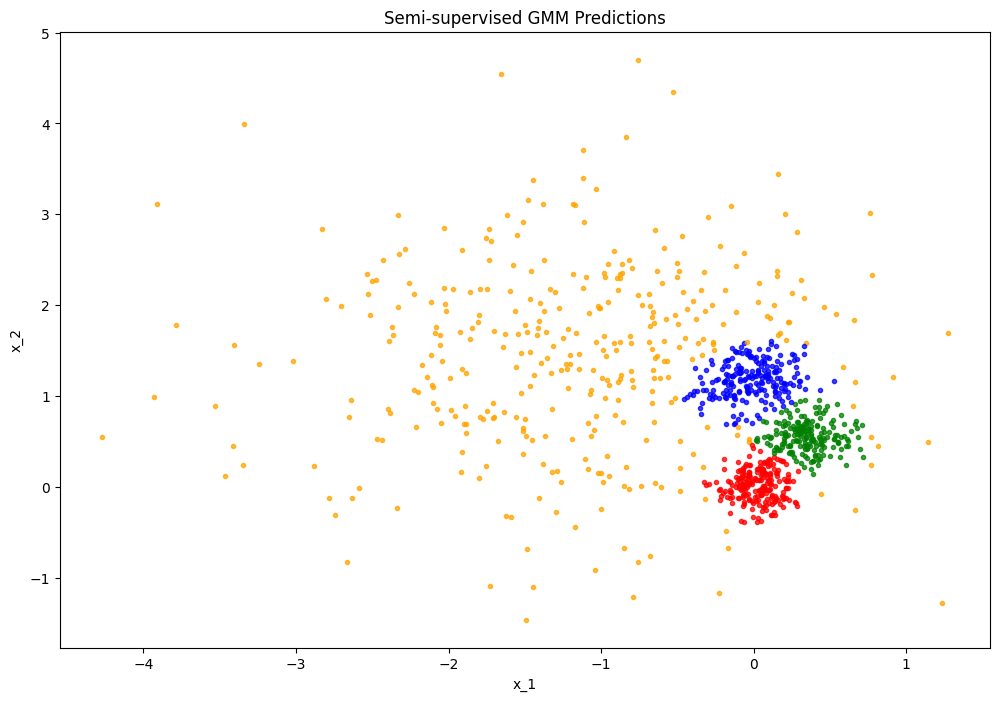

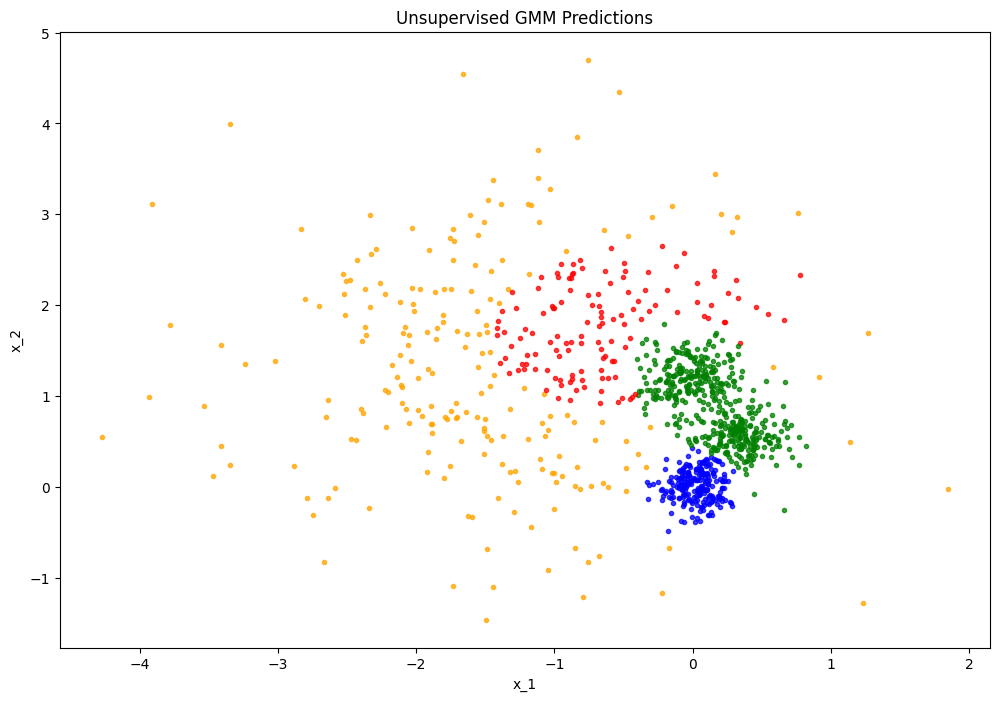

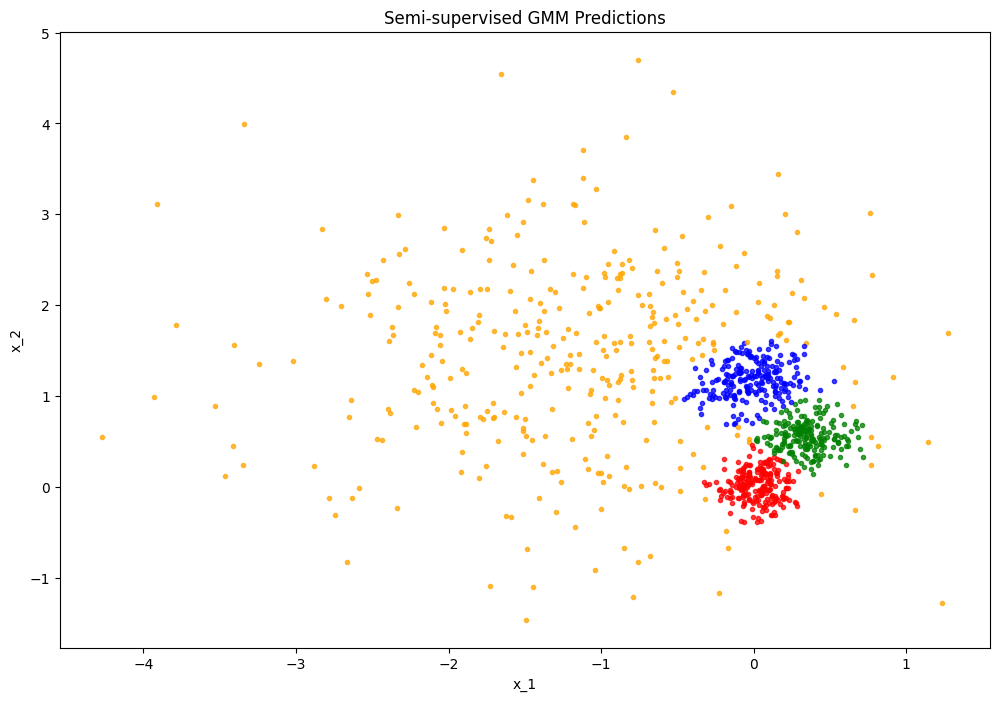

In [63]:
np.random.seed(229)
# Run NUM_TRIALS trials to see how different initializations
# affect the final predictions with and without supervision
for t in range(NUM_TRIALS):
    main(is_semi_supervised=False, trial_num=t)
    main(is_semi_supervised=True, trial_num=t)